# WODB DATA
In this notebook we read in all the WODB data for the bottom temperature and bottom salinity indicators

In [71]:
#import necessary packages
import numpy as np
import pandas as pn
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline
import regionmask
import geopandas as gpd
import cartopy.crs as ccrs
import gsw
from matplotlib.ticker import MaxNLocator
import plotly.express as px
import warnings
import seabird
from seabird.cnv import fCNV

In [ ]:
#assign arbitrary column names
col_names = ['one','two','three','four','five','six','seven','eight','nine','ten','eleven','twelve','thirteen','fourteen','fifteen','sixteen','seventeen','eighteen']


In [ ]:
# This is CTD data on standard levels.
ctd = pn.read_csv('/Users/lauragruenburg/Downloads/ocldb1755620923.2655590.CTD.csv', skipinitialspace=True,names=['one','two','three','four','five','six','seven','eight','nine','ten','eleven','twelve','thirteen','fourteen','fifteen','sixteen','seventeen','eighteen'])

In [ ]:
# This is CTD on observed levels.  I have chosen to use observed levels from now on as it likely gives up a number closer to the sctual bottom
ctd2 = pn.read_csv('/Users/lauragruenburg/Downloads/ocldb1756215237.80409.CTD.csv', skipinitialspace = True, names = col_names)

In [ ]:
starts = ctd2[ctd2.one=='#--------------------------------------------------------------------------------'].index
len(starts)-1

In [ ]:
#Function for rearranging the CTD data in a more readable way
def get_ctd(ctd_csv):


    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        starts = ctd_csv[ctd_csv.one=='#--------------------------------------------------------------------------------'].index
        
        #Make the initial dataframe with the first cast
        i=0
        cast = ctd_csv[starts[i]:starts[i+1]]
        cast['one'] = cast['one'].map(str.strip)
        Latitude = cast[cast['one'].str.contains('Latitude')].three.values.astype('float')
        Longitude = cast[cast['one'].str.contains('Longitude')].three.values.astype('float')
        Year = cast[cast['one'].str.contains('Year')].three.values.astype(int)
        Month = cast[cast['one'].str.contains('Month')].three.values.astype(int)
        Day = cast[cast['one'].str.contains('Day')].three.values.astype(int)
        date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])
        date = pn.to_datetime(date_str)
        Prof_Flag = cast[cast['one'].str.contains('Prof-Flag')].three.values.astype('int')
        start = cast[cast['one'].str.contains('VARIABLES')].index[0]
        stop = cast[cast['one'].str.contains('VARIABLES')].index[1]
        
        yndepth = np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0].any()
        yntemp = np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0].any()
        ynsalt = np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0].any()
        ynph = np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0].any()
        ynoxygen = np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0].any()
        
        if yndepth == True:
            Depth = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
            Depth_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]+1]]
        
        if yntemp == True:
            Temp = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]
            Temp_var = Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values
            Temp_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]+1]]
            Temp_flag_var = Temp_flag.reset_index()[2:][Temp_flag.reset_index()[2:].columns[1]].values
        else:
            Temp_var = np.full(len(Depth.reset_index()[2:]), np.nan)
            Temp_flag_var = npnp.full(len(Depth.reset_index()[2:]), np.nan)
        
        if  ynsalt == True:
            Salt = cast[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]]]
            Salt_var = Salt.reset_index()[2:][Salt.reset_index()[2:].columns[1]].values
            Salt_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]+1]]
            Salt_flag_var = Salt_flag.reset_index()[2:][Salt_flag.reset_index()[2:].columns[1]].values
        else:
            Salt_var = np.full(len(Depth.reset_index()[2:]), np.nan)
            Salt_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
        if  ynph == True:
            pH = cast[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]]]
            pH_var = pH.reset_index()[2:][pH.reset_index()[2:].columns[1]].values
            pH_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]+1]]
            pH_flag_var = pH_flag.reset_index()[2:][pH_flag.reset_index()[2:].columns[1]].values
        else:
            pH_var = np.full(len(Depth.reset_index()[2:]), np.nan)
            pH_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
        if  ynoxygen == True:
            Oxygen = cast[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]]]
            Oxygen_var = Oxygen.reset_index()[2:][Oxygen.reset_index()[2:].columns[1]].values
            Oxygen_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]+1]]
            Oxygen_flag_var = Oxygen_flag.reset_index()[2:][Oxygen_flag.reset_index()[2:].columns[1]].values
        else:
            Oxygen_var = np.full(len(Depth.reset_index()[2:]), np.nan)
            Oxygen_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
        
        ctd_casts = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                                  'date': np.repeat(date, len(Depth.reset_index()[2:])),
                                  'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                                  'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                                  'Prof-Flag': np.repeat(Prof_Flag, len(Depth.reset_index()[2:])),
                                  'Depth': Depth.reset_index()[2:].two.values,
                                  'Depth-Flag': Depth_flag.reset_index()[2:][Depth_flag.reset_index()[2:].columns[1]].values,
                                  'Temp': Temp_var,
                                  'Temp-Flag': Temp_flag_var,
                                  'Salt': Salt_var,
                                  'Salt-Flag': Salt_flag_var,
                                  'pH': pH_var,
                                  'pH-Flag': pH_flag_var,
                                  'Oxygen': Oxygen_var,
                                  'Oxygen-Flag': Oxygen_flag_var})
    
        for i in np.arange(1,len(starts)-1):
            cast = ctd_csv[starts[i]:starts[i+1]]
            cast['one'] = cast['one'].map(str.strip)
            if cast[cast['one'].str.contains('VARIABLES')].any().any() == True:
                Latitude = cast[cast['one'].str.contains('Latitude')].three.values.astype('float')
                Longitude = cast[cast['one'].str.contains('Longitude')].three.values.astype('float')
                Year = cast[cast['one'].str.contains('Year')].three.values.astype(int)
                Month = cast[cast['one'].str.contains('Month')].three.values.astype(int)
                Day = cast[cast['one'].str.contains('Day')].three.values.astype(int)
                date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])
                date = pn.to_datetime(date_str)
                Prof_Flag = cast[cast['one'].str.contains('Prof-Flag')].three.values.astype('int')
                start = cast[cast['one'].str.contains('VARIABLES')].index[0]
                stop = cast[cast['one'].str.contains('VARIABLES')].index[1]
        
                yndepth = np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0].any()
                yntemp = np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0].any()
                ynsalt = np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0].any()
                ynph = np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0].any()
                ynoxygen = np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0].any()
        
                if yndepth == True:
                    Depth = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
                    Depth_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]+1]]
        
                if yntemp == True:
                    Temp = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]
                    Temp_var = Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values
                    Temp_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]+1]]
                    Temp_flag_var = Temp_flag.reset_index()[2:][Temp_flag.reset_index()[2:].columns[1]].values
                else:
                    Temp_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                    Temp_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
        
                if  ynsalt == True:
                    Salt = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]]]
                    Salt_var = Salt.reset_index()[2:][Salt.reset_index()[2:].columns[1]].values
                    Salt_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]+1]]
                    Salt_flag_var = Salt_flag.reset_index()[2:][Salt_flag.reset_index()[2:].columns[1]].values
                else:
                    Salt_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                    Salt_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                if  ynph == True:
                    pH = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]]]
                    pH_var = pH.reset_index()[2:][pH.reset_index()[2:].columns[1]].values
                    pH_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]+1]]
                    pH_flag_var = pH_flag.reset_index()[2:][pH_flag.reset_index()[2:].columns[1]].values
                else:
                    pH_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                    pH_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                if  ynoxygen == True:
                    Oxygen = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]]]
                    Oxygen_var = Oxygen.reset_index()[2:][Oxygen.reset_index()[2:].columns[1]].values
                    Oxygen_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]+1]]
                    Oxygen_flag_var = Oxygen_flag.reset_index()[2:][Oxygen_flag.reset_index()[2:].columns[1]].values
                else:
                    Oxygen_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                    Oxygen_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    
                df = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                                      'date': np.repeat(date, len(Depth.reset_index()[2:])),
                                      'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                                      'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                                      'Prof-Flag': np.repeat(Prof_Flag, len(Depth.reset_index()[2:])),
                                      'Depth': Depth.reset_index()[2:].two.values,
                                      'Depth-Flag': Depth_flag.reset_index()[2:][Depth_flag.reset_index()[2:].columns[1]].values,
                                      'Temp': Temp_var,
                                      'Temp-Flag': Temp_flag_var,
                                      'Salt': Salt_var,
                                      'Salt-Flag': Salt_flag_var,
                                      'pH': pH_var,
                                      'pH-Flag': pH_flag_var,
                                      'Oxygen': Oxygen_var,
                                      'Oxygen-Flag': Oxygen_flag_var})
                ctd_casts = pn.concat([ctd_casts, df])
    return ctd_casts

In [ ]:
ctd_casts2 = get_ctd(ctd2)

In [ ]:
ctd_casts2


In [ ]:
cast = ctd2[starts[-1]:]
cast['one'] = cast['one'].map(str.strip)
Latitude = cast[cast['one'].str.contains('Latitude')].three.values.astype('float')
Longitude = cast[cast['one'].str.contains('Longitude')].three.values.astype('float')
Year = cast[cast['one'].str.contains('Year')].three.values.astype(int)
Month = cast[cast['one'].str.contains('Month')].three.values.astype(int)
Day = cast[cast['one'].str.contains('Day')].three.values.astype(int)
date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])
date = pn.to_datetime(date_str)
Prof_Flag = cast[cast['one'].str.contains('Prof-Flag')].three.values.astype('int')
start = cast[cast['one'].str.contains('VARIABLES')].index[0]
stop = cast[cast['one'].str.contains('VARIABLES')].index[1]

yndepth = np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0].any()
yntemp = np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0].any()
ynsalt = np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0].any()
ynph = np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0].any()
ynoxygen = np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0].any()

if yndepth == True:
    Depth = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
    Depth_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]+1]]

if yntemp == True:
    Temp = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]
    Temp_var = Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values
    Temp_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]+1]]
    Temp_flag_var = Temp_flag.reset_index()[2:][Temp_flag.reset_index()[2:].columns[1]].values
else:
    Temp_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    Temp_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)

if  ynsalt == True:
    Salt = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]]]
    Salt_var = Salt.reset_index()[2:][Salt.reset_index()[2:].columns[1]].values
    Salt_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]+1]]
    Salt_flag_var = Salt_flag.reset_index()[2:][Salt_flag.reset_index()[2:].columns[1]].values
else:
    Salt_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    Salt_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
if  ynph == True:
    pH = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]]]
    pH_var = pH.reset_index()[2:][pH.reset_index()[2:].columns[1]].values
    pH_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]+1]]
    pH_flag_var = pH_flag.reset_index()[2:][pH_flag.reset_index()[2:].columns[1]].values
else:
    pH_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    pH_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
if  ynoxygen == True:
    Oxygen = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]]]
    Oxygen_var = Oxygen.reset_index()[2:][Oxygen.reset_index()[2:].columns[1]].values
    Oxygen_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]+1]]
    Oxygen_flag_var = Oxygen_flag.reset_index()[2:][Oxygen_flag.reset_index()[2:].columns[1]].values
else:
    Oxygen_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    Oxygen_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)

df = pn.DataFrame({'cast_number': np.repeat(28651, len(Depth.reset_index()[2:])),
                      'date': np.repeat(date, len(Depth.reset_index()[2:])),
                      'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                      'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                      'Prof-Flag': np.repeat(Prof_Flag, len(Depth.reset_index()[2:])),
                      'Depth': Depth.reset_index()[2:].two.values,
                      'Depth-Flag': Depth_flag.reset_index()[2:][Depth_flag.reset_index()[2:].columns[1]].values,
                      'Temp': Temp_var,
                      'Temp-Flag': Temp_flag_var,
                      'Salt': Salt_var,
                      'Salt-Flag': Salt_flag_var,
                      'pH': pH_var,
                      'pH-Flag': pH_flag_var,
                      'Oxygen': Oxygen_var,
                   'Oxygen-Flag': Oxygen_flag_var})

In [ ]:
df

In [ ]:
ctd_casts2 = pn.concat([ctd_casts2, df])

In [ ]:
ctd_casts2 = ctd_casts2.reset_index(drop=True)

In [ ]:
#ctd_casts2.to_csv('CTD_WODB2025.csv')

In [2]:
ctd_casts2 = pn.read_csv('CTD_WODB2025.csv')

/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_79662/1570536902.py:1: DtypeWarning: Columns (8,10,14) have mixed types. Specify dtype option on import or set low_memory=False.
  ctd_casts2 = pn.read_csv('CTD_WODB2025.csv')


In [82]:
ctd_seawolf = pn.read_csv('~/Desktop/NYB_Indicators_Calculations/CalculateIndicators/WaterTemperature/data/CTD_seawolf_Nov_3_2025.csv')


In [3]:
salt_yes = ctd_casts2[~pn.isna(ctd_casts2.Salt)]

In [4]:
salt_yes_yes = salt_yes[salt_yes['Salt-Flag'].astype('int') == 0]

In [5]:
temp_yes_salt_yes_yes = salt_yes_yes[~pn.isna(salt_yes_yes.Temp)]

In [6]:
temp_yes_yes_salt_yes_yes = temp_yes_salt_yes_yes[temp_yes_salt_yes_yes['Temp-Flag'].astype('int') == 0].reset_index(drop = True)

In [7]:
pn.unique(temp_yes_yes_salt_yes_yes['Depth-Flag']) #looks like 2 is for a density inversion, ill leave it in

array([0., 2.])

In [8]:
temp_yy_salt_yy = temp_yes_yes_salt_yes_yes[~(temp_yes_yes_salt_yes_yes.Salt == '---*---')]

In [9]:
temp_yy_salt_yy = temp_yy_salt_yy[~(temp_yy_salt_yy.Temp == '---*---')]

In [10]:
temp_yy_salt_yy['p'] = gsw.p_from_z(-1*temp_yy_salt_yy.Depth.astype('float'), temp_yy_salt_yy.Latitude.astype('float'))

In [11]:
temp_yy_salt_yy['SA'] = gsw.SA_from_SP(temp_yy_salt_yy.Salt.astype('float'),
                                       temp_yy_salt_yy.p.astype('float'),
                                       temp_yy_salt_yy.Longitude.astype('float'),
                                       temp_yy_salt_yy.Latitude.astype('float'))

In [85]:
ctd_seawolf['SA'] = gsw.SA_from_SP(ctd_seawolf.salt,
                                   ctd_seawolf.pressure,
                                   ctd_seawolf.lon,
                                   ctd_seawolf.lat)

In [12]:
temp_yy_salt_yy['CT'] = gsw.CT_from_t(temp_yy_salt_yy.SA.astype('float'),
                                      temp_yy_salt_yy.Temp.astype('float'),
                                      temp_yy_salt_yy.p.astype('float'))

In [87]:
ctd_seawolf['CT'] = gsw.CT_from_t(ctd_seawolf.SA,
                                ctd_seawolf.temp,
                                ctd_seawolf.pressure)

In [13]:
temp_yy_salt_yy['sigma'] = gsw.sigma0(temp_yy_salt_yy.SA.astype('float'),
                                      temp_yy_salt_yy.CT.astype('float'))

In [89]:
ctd_seawolf['sigma'] = gsw.sigma0(ctd_seawolf.SA,
                                 ctd_seawolf.CT)

In [ ]:
P = 1/H integral(-h, n)[pbar - p]gz dz

In [ ]:
(np.mean(cast1d.sigma) - cast1d.sigma)


In [ ]:
kg/ms2
(1/m) * (kg/) * (1/s2 * 


In [ ]:
cast1 = temp_yy_salt_yy[temp_yy_salt_yy.cast_number == 2]
cast1d = cast1[cast1.Depth.astype(float) <= 200]
P_c1d = (1/(-199.4)) * sum((np.mean(cast1d.sigma) - cast1d.sigma) * (9.8 * (-1*cast1d.Depth.astype(float))) * np.append(-3,np.diff(-1*cast1d.Depth.astype(float))))


In [91]:
ctd_seawolf

          

,Unnamed: 0,lat,lon,date,depth,pressure,temp,salt,density,profn,SA,CT,sigma
0,1,40.509267,-73.444217,2020-06-09 21:26:36,1.0,0.787,17.9419,29.9258,1021.4085,1,30.067693,18.077846,21.410049
1,2,40.509267,-73.444217,2020-06-09 21:26:36,2.0,2.023,17.9671,29.9133,1021.3979,1,30.055136,18.103377,21.394557
2,3,40.509267,-73.444217,2020-06-09 21:26:36,3.0,2.952,17.9763,29.9018,1021.3921,1,30.043583,18.112816,21.383620
3,4,40.509267,-73.444217,2020-06-09 21:26:36,4.0,4.086,17.9248,29.9036,1021.4093,1,30.045394,18.060703,21.397283
4,5,40.509267,-73.444217,2020-06-09 21:26:36,5.0,5.080,17.8923,29.8971,1021.4195,1,30.038865,18.027987,21.400070
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246953,1246954,40.509267,-73.444217,2020-06-09 21:26:36,10.0,10.055,12.3461,31.4559,1023.8162,480,31.605066,12.409840,23.778301
1246954,1246955,40.509267,-73.444217,2020-06-09 21:26:36,11.0,11.075,11.9795,31.6014,1024.0042,480,31.751256,12.038450,23.959129
1246955,1246956,40.509267,-73.444217,2020-06-09 21:26:36,12.0,12.059,11.7621,31.6874,1024.1153,480,31.837665,11.818244,24.065619
1246956,1246957,40.509267,-73.444217,2020-06-09 21:26:36,13.0,13.065,11.6502,31.7131,1024.1603,480,31.863487,11.705237,24.105872


In [ ]:
cast14 = temp_yy_salt_yy[temp_yy_salt_yy.cast_number == 14]
cast14d = cast14[cast14.Depth.astype(float) <= 200]
P_c14d = (1/(-199.4)) * sum((np.mean(cast14d.sigma) - cast14d.sigma) * (9.8 * (-1*cast14d.Depth.astype(float))) * np.append(-3,np.diff(-1*cast14d.Depth.astype(float))))
P_c14d

In [ ]:
plt.plot(cast1d.sigma.astype(float), cast1d.Depth.astype(float))
plt.plot(cast14d.sigma.astype(float), cast14d.Depth.astype(float))
plt.show()

In [ ]:
temp_yy_salt_yy['pea'] = 0

In [92]:
ctd_seawolf['pea'] = 0
ctd_seawolf


,Unnamed: 0,lat,lon,date,depth,pressure,temp,salt,density,profn,SA,CT,sigma,pea
0,1,40.509267,-73.444217,2020-06-09 21:26:36,1.0,0.787,17.9419,29.9258,1021.4085,1,30.067693,18.077846,21.410049,0
1,2,40.509267,-73.444217,2020-06-09 21:26:36,2.0,2.023,17.9671,29.9133,1021.3979,1,30.055136,18.103377,21.394557,0
2,3,40.509267,-73.444217,2020-06-09 21:26:36,3.0,2.952,17.9763,29.9018,1021.3921,1,30.043583,18.112816,21.383620,0
3,4,40.509267,-73.444217,2020-06-09 21:26:36,4.0,4.086,17.9248,29.9036,1021.4093,1,30.045394,18.060703,21.397283,0
4,5,40.509267,-73.444217,2020-06-09 21:26:36,5.0,5.080,17.8923,29.8971,1021.4195,1,30.038865,18.027987,21.400070,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246953,1246954,40.509267,-73.444217,2020-06-09 21:26:36,10.0,10.055,12.3461,31.4559,1023.8162,480,31.605066,12.409840,23.778301,0
1246954,1246955,40.509267,-73.444217,2020-06-09 21:26:36,11.0,11.075,11.9795,31.6014,1024.0042,480,31.751256,12.038450,23.959129,0
1246955,1246956,40.509267,-73.444217,2020-06-09 21:26:36,12.0,12.059,11.7621,31.6874,1024.1153,480,31.837665,11.818244,24.065619,0
1246956,1246957,40.509267,-73.444217,2020-06-09 21:26:36,13.0,13.065,11.6502,31.7131,1024.1603,480,31.863487,11.705237,24.105872,0


In [ ]:
i=2
cast = temp_yy_salt_yy[temp_yy_salt_yy.cast_number == i]
cast_depth = cast[cast.Depth.astype(float) <= 200]
pe = (1/(-1*np.max(cast_depth.Depth.astype(float)))) * sum((np.mean(cast_depth.sigma) - cast_depth.sigma) * (9.8 * (-1*cast_depth.Depth.astype(float))) * np.append((-1*np.min(cast_depth.Depth.astype(float))),np.diff(-1*cast_depth.Depth.astype(float))))
temp_yy_salt_yy.loc[temp_yy_salt_yy.cast_number == i, 'pea'] = pe
temp_yy_salt_yy

In [ ]:
cast = temp_yy_salt_yy[temp_yy_salt_yy.cast_number == i]
cast_depth = cast[cast.Depth.astype(float) <= 200]
if len(cast_depth) < 2: 
    temp_yy_salt_yy.loc[temp_yy_salt_yy.cast_number == i, 'pea'] = np.nan

In [15]:
for i in np.unique(temp_yy_salt_yy.cast_number):
    cast = temp_yy_salt_yy[temp_yy_salt_yy.cast_number == i]
    cast_depth = cast[cast.Depth.astype(float) <= 200]
    if len(cast_depth) <2: 
        temp_yy_salt_yy.loc[temp_yy_salt_yy.cast_number == i, 'pea'] = np.nan
    else:
        pe = (1/(-1*np.max(cast_depth.Depth.astype(float)))) * sum((np.mean(cast_depth.sigma) - cast_depth.sigma) * (9.8 * (-1*cast_depth.Depth.astype(float))) * np.append((-1*np.min(cast_depth.Depth.astype(float))),np.diff(-1*cast_depth.Depth.astype(float))))
        temp_yy_salt_yy.loc[temp_yy_salt_yy.cast_number == i, 'pea'] = pe

In [110]:
for i in np.unique(ctd_seawolf.profn):
    cast = ctd_seawolf[ctd_seawolf.profn == i]
    cast_depth = cast[cast.depth <= 200]
    if len(cast_depth) <2: 
        ctd_seawolf.loc[ctd_seawolf.profn == i, 'pea'] = np.nan
    else:
        pe = (1/(-1*np.max(cast_depth.depth))) * sum((np.mean(cast_depth.sigma) - cast_depth.sigma) * (9.8 * (-1*cast_depth.depth)) * np.append((-1*np.min(cast_depth.depth)),np.diff(-1*cast_depth.depth)))
        ctd_seawolf.loc[ctd_seawolf.profn == i, 'pea'] = pe

In [111]:
# identify which ones are in the nyb polygon
NYB = gpd.read_file('Datasets/Shapefiles/PlanningArea_NYocean_NYSDOS.shp')

In [112]:
NYB = NYB.to_crs('EPSG:4326')
NYB

,ID,area_m,dummy,Shape_Leng,Shape_Area,Area_SqMi,geometry
0,0.0,43471.799751,0,910713.7766,4.347178e+10,16784.548944,"POLYGON ((-71.66879 41.05893, -71.64509 40.949..."


In [19]:
temp_yy_salt_yy['geometry'] = gpd.points_from_xy(temp_yy_salt_yy.Longitude, temp_yy_salt_yy.Latitude, crs="EPSG:4326")
temp_yy_salt_yy_gpd = gpd.GeoDataFrame(data=temp_yy_salt_yy, geometry='geometry')

temp_yy_salt_yy_nyb = gpd.sjoin(left_df=temp_yy_salt_yy_gpd, right_df=NYB, how='left')

In [113]:
ctd_seawolf['geometry'] = gpd.points_from_xy(ctd_seawolf.lon, ctd_seawolf.lat, crs="EPSG:4326")
ctd_seawolf_gpd = gpd.GeoDataFrame(data=ctd_seawolf, geometry='geometry')

ctd_seawolf_nyb = gpd.sjoin(left_df=ctd_seawolf_gpd, right_df=NYB, how='left')

In [20]:
temp_yy_salt_yy_nyb = temp_yy_salt_yy_nyb[np.isnan(temp_yy_salt_yy_nyb['Area_SqMi']) == False]

In [114]:
ctd_seawolf_nyb = ctd_seawolf_nyb[np.isnan(ctd_seawolf_nyb['Area_SqMi']) == False]

In [21]:
temp_yy_salt_yy_nyb = temp_yy_salt_yy_nyb.drop(['index_right', 'ID', 'area_m', 'dummy', 'Shape_Leng', 'Shape_Area', 'Area_SqMi'], axis = 1).reset_index(drop = True)


In [115]:
ctd_seawolf_nyb = ctd_seawolf_nyb.drop(['index_right', 'ID', 'area_m', 'dummy', 'Shape_Leng', 'Shape_Area', 'Area_SqMi'], axis = 1).reset_index(drop = True)


In [116]:
ctd_seawolf_nyb

,Unnamed: 0,lat,lon,date,depth,pressure,temp,salt,density,profn,SA,CT,sigma,pea,geometry
0,1,40.509267,-73.444217,2020-06-09 21:26:36,1.0,0.787,17.9419,29.9258,1021.4085,1,30.067693,18.077846,21.410049,43.978684,POINT (-73.44422 40.50927)
1,2,40.509267,-73.444217,2020-06-09 21:26:36,2.0,2.023,17.9671,29.9133,1021.3979,1,30.055136,18.103377,21.394557,43.978684,POINT (-73.44422 40.50927)
2,3,40.509267,-73.444217,2020-06-09 21:26:36,3.0,2.952,17.9763,29.9018,1021.3921,1,30.043583,18.112816,21.383620,43.978684,POINT (-73.44422 40.50927)
3,4,40.509267,-73.444217,2020-06-09 21:26:36,4.0,4.086,17.9248,29.9036,1021.4093,1,30.045394,18.060703,21.397283,43.978684,POINT (-73.44422 40.50927)
4,5,40.509267,-73.444217,2020-06-09 21:26:36,5.0,5.080,17.8923,29.8971,1021.4195,1,30.038865,18.027987,21.400070,43.978684,POINT (-73.44422 40.50927)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1212058,1246954,40.509267,-73.444217,2020-06-09 21:26:36,10.0,10.055,12.3461,31.4559,1023.8162,480,31.605066,12.409840,23.778301,43.978684,POINT (-73.44422 40.50927)
1212059,1246955,40.509267,-73.444217,2020-06-09 21:26:36,11.0,11.075,11.9795,31.6014,1024.0042,480,31.751256,12.038450,23.959129,43.978684,POINT (-73.44422 40.50927)
1212060,1246956,40.509267,-73.444217,2020-06-09 21:26:36,12.0,12.059,11.7621,31.6874,1024.1153,480,31.837665,11.818244,24.065619,43.978684,POINT (-73.44422 40.50927)
1212061,1246957,40.509267,-73.444217,2020-06-09 21:26:36,13.0,13.065,11.6502,31.7131,1024.1603,480,31.863487,11.705237,24.105872,43.978684,POINT (-73.44422 40.50927)


In [22]:
def get_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [32]:
pn.to_datetime(temp_yy_salt_yy_nyb['date']).dt.month

0          2
1          2
2          2
3          2
4          2
          ..
703757    11
703758    11
703759    11
703760    11
703761    11
Name: date, Length: 703762, dtype: int32

In [33]:
temp_yy_salt_yy_nyb['Season'] = pn.to_datetime(temp_yy_salt_yy_nyb['date']).dt.month.apply(get_season)

In [34]:
temp_yy_salt_yy_nyb['month'] = pn.to_datetime(temp_yy_salt_yy_nyb['date']).dt.month

In [117]:
ctd_seawolf_nyb['Season'] = pn.to_datetime(ctd_seawolf_nyb['date']).dt.month.apply(get_season)

In [118]:
ctd_seawolf_nyb['month'] = pn.to_datetime(ctd_seawolf_nyb['date']).dt.month

In [36]:
temp_yy_salt_yy_nyb['year'] = pn.to_datetime(temp_yy_salt_yy_nyb['date']).dt.year

In [39]:
temp_yy_salt_yy_nyb['season_year'] = temp_yy_salt_yy_nyb.year


In [40]:
temp_yy_salt_yy_nyb.loc[temp_yy_salt_yy_nyb.month == 12, 'season_year'] = temp_yy_salt_yy_nyb.loc[temp_yy_salt_yy_nyb.month == 12, 'year'] + 1



In [121]:
ctd_seawolf_nyb['year'] = pn.to_datetime(ctd_seawolf_nyb['date']).dt.year

In [122]:
ctd_seawolf_nyb['season_year'] = ctd_seawolf_nyb.year


In [123]:
ctd_seawolf_nyb.loc[ctd_seawolf_nyb.month == 12, 'season_year'] = ctd_seawolf_nyb.loc[ctd_seawolf_nyb.month == 12, 'year'] + 1



In [131]:
ctd_seawolf

,Unnamed: 0,lat,lon,date,depth,pressure,temp,salt,density,profn,SA,CT,sigma,pea,geometry
0,1,40.509267,-73.444217,2020-06-09 21:26:36,1.0,0.787,17.9419,29.9258,1021.4085,1,30.067693,18.077846,21.410049,43.978684,POINT (-73.44422 40.50927)
1,2,40.509267,-73.444217,2020-06-09 21:26:36,2.0,2.023,17.9671,29.9133,1021.3979,1,30.055136,18.103377,21.394557,43.978684,POINT (-73.44422 40.50927)
2,3,40.509267,-73.444217,2020-06-09 21:26:36,3.0,2.952,17.9763,29.9018,1021.3921,1,30.043583,18.112816,21.383620,43.978684,POINT (-73.44422 40.50927)
3,4,40.509267,-73.444217,2020-06-09 21:26:36,4.0,4.086,17.9248,29.9036,1021.4093,1,30.045394,18.060703,21.397283,43.978684,POINT (-73.44422 40.50927)
4,5,40.509267,-73.444217,2020-06-09 21:26:36,5.0,5.080,17.8923,29.8971,1021.4195,1,30.038865,18.027987,21.400070,43.978684,POINT (-73.44422 40.50927)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246953,1246954,40.509267,-73.444217,2020-06-09 21:26:36,10.0,10.055,12.3461,31.4559,1023.8162,480,31.605066,12.409840,23.778301,43.978684,POINT (-73.44422 40.50927)
1246954,1246955,40.509267,-73.444217,2020-06-09 21:26:36,11.0,11.075,11.9795,31.6014,1024.0042,480,31.751256,12.038450,23.959129,43.978684,POINT (-73.44422 40.50927)
1246955,1246956,40.509267,-73.444217,2020-06-09 21:26:36,12.0,12.059,11.7621,31.6874,1024.1153,480,31.837665,11.818244,24.065619,43.978684,POINT (-73.44422 40.50927)
1246956,1246957,40.509267,-73.444217,2020-06-09 21:26:36,13.0,13.065,11.6502,31.7131,1024.1603,480,31.863487,11.705237,24.105872,43.978684,POINT (-73.44422 40.50927)


In [133]:
ctd_seawolf_nyb.rename(columns={'lat': 'Latitude',
                            'lon': 'Longitude',
                               'profn': 'cast number'})
ctd_seawolf_nyb

,Unnamed: 0,lat,lon,date,depth,pressure,temp,salt,density,profn,SA,CT,sigma,pea,geometry,Season,month,year,season_year
0,1,40.509267,-73.444217,2020-06-09 21:26:36,1.0,0.787,17.9419,29.9258,1021.4085,1,30.067693,18.077846,21.410049,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020
1,2,40.509267,-73.444217,2020-06-09 21:26:36,2.0,2.023,17.9671,29.9133,1021.3979,1,30.055136,18.103377,21.394557,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020
2,3,40.509267,-73.444217,2020-06-09 21:26:36,3.0,2.952,17.9763,29.9018,1021.3921,1,30.043583,18.112816,21.383620,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020
3,4,40.509267,-73.444217,2020-06-09 21:26:36,4.0,4.086,17.9248,29.9036,1021.4093,1,30.045394,18.060703,21.397283,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020
4,5,40.509267,-73.444217,2020-06-09 21:26:36,5.0,5.080,17.8923,29.8971,1021.4195,1,30.038865,18.027987,21.400070,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1212058,1246954,40.509267,-73.444217,2020-06-09 21:26:36,10.0,10.055,12.3461,31.4559,1023.8162,480,31.605066,12.409840,23.778301,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020
1212059,1246955,40.509267,-73.444217,2020-06-09 21:26:36,11.0,11.075,11.9795,31.6014,1024.0042,480,31.751256,12.038450,23.959129,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020
1212060,1246956,40.509267,-73.444217,2020-06-09 21:26:36,12.0,12.059,11.7621,31.6874,1024.1153,480,31.837665,11.818244,24.065619,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020
1212061,1246957,40.509267,-73.444217,2020-06-09 21:26:36,13.0,13.065,11.6502,31.7131,1024.1603,480,31.863487,11.705237,24.105872,43.978684,POINT (-73.44422 40.50927),Summer,6,2020,2020


In [174]:
a = pn.DataFrame(temp_yy_salt_yy_nyb[temp_yy_salt_yy_nyb.cast_number == 38].reset_index().iloc[0:1,:])
b = pn.DataFrame(temp_yy_salt_yy_nyb[temp_yy_salt_yy_nyb.cast_number == 40].reset_index().iloc[0:1,:])
pn.concat([a,b]).reset_index()

,level_0,index,Unnamed: 0,cast_number,date,Latitude,Longitude,Prof-Flag,Depth,Depth-Flag,...,p,SA,CT,sigma,pea,geometry,Season,month,year,season_year
0,0,0,58067,38,1975-02-22,39.300,-73.230,0,0.0,0.0,...,0.0,33.970242,7.389164,26.430711,4.291112,POINT (-73.23 39.3),Winter,2,1975,1975
1,0,52,58167,40,1975-02-23,39.588,-73.372,0,0.0,0.0,...,0.0,33.578416,6.203347,26.282130,4.108017,POINT (-73.372 39.588),Winter,2,1975,1975


In [177]:
ctdwodb = pn.DataFrame(temp_yy_salt_yy_nyb[temp_yy_salt_yy_nyb.cast_number == 38].reset_index().iloc[0:1,:])

for i in np.unique(temp_yy_salt_yy_nyb.cast_number):
    if i == 38:
        continue
    else:
        first_line = pn.DataFrame(temp_yy_salt_yy_nyb[temp_yy_salt_yy_nyb.cast_number == i].reset_index().iloc[0:1,:])
        ctdwodb = pn.concat([ctdwodb, first_line]).reset_index(drop = True)
        

In [180]:
ctdseawolf = pn.DataFrame(ctd_seawolf_nyb[ctd_seawolf_nyb.profn == 1].reset_index().iloc[0:1,:])

for i in np.unique(ctd_seawolf_nyb.profn):
    if i == 1:
        continue
    else:
        first_line = pn.DataFrame(ctd_seawolf_nyb[ctd_seawolf_nyb.profn == i].reset_index().iloc[0:1,:])
        ctdseawolf = pn.concat([ctdseawolf, first_line]).reset_index(drop = True)

In [210]:
all_ctd = pn.concat([ctdwodb, ctdseawolf], axis = 0, join = 'inner', ignore_index = True)

In [211]:
all_ctd

,index,Unnamed: 0,date,SA,CT,sigma,pea,geometry,Season,month,year,season_year
0,0,58067,1975-02-22,33.970242,7.389164,26.430711,4.291112,POINT (-73.23 39.3),Winter,2,1975,1975
1,52,58167,1975-02-23,33.578416,6.203347,26.282130,4.108017,POINT (-73.372 39.588),Winter,2,1975,1975
2,89,58206,1975-02-23,34.110927,7.777352,26.485107,1.629254,POINT (-73.108 39.925),Winter,2,1975,1975
3,142,58261,1975-02-23,34.151101,7.996880,26.484328,5.209149,POINT (-72.98 39.788),Winter,2,1975,1975
4,196,58317,1975-02-23,33.809462,7.501548,26.289395,4.472697,POINT (-72.412 39.898),Winter,2,1975,1975
...,...,...,...,...,...,...,...,...,...,...,...,...
9223,1211927,1246823,2020-06-09 16:32:55,30.803563,18.593837,21.841012,101.547262,POINT (-73.64833 40.10923),Summer,6,2020,2020
9224,1211965,1246861,2020-06-09 17:56:26,31.685812,17.316538,22.809783,68.808496,POINT (-73.32713 40.17117),Summer,6,2020,2020
9225,1212002,1246898,2020-06-09 18:00:56,31.681592,17.300481,22.810330,69.663390,POINT (-73.32713 40.17258),Summer,6,2020,2020
9226,1212038,1246934,2020-06-09 21:23:37,30.037553,18.148200,21.370711,28.069665,POINT (-73.44563 40.50825),Summer,6,2020,2020


In [212]:
season_counts = all_ctd.groupby(['Season','season_year']).size()
season_counts.Autumn[season_counts.Autumn <5] # Autumns with less than 10 profiles - need to remove

season_year
1983    1
dtype: int64

In [213]:
all_ctd = all_ctd.drop(all_ctd.loc[(all_ctd.Season == 'Autumn') & (all_ctd.season_year == 1983)].index)

In [214]:
season_counts.Winter[season_counts.Winter <5]

Series([], dtype: int64)

In [215]:
season_counts.Spring[season_counts.Spring <5]

Series([], dtype: int64)

In [216]:
season_counts.Summer[season_counts.Summer <5]

season_year
1982    3
2014    1
2015    1
dtype: int64

In [217]:
all_ctd = all_ctd.drop(all_ctd.loc[(all_ctd.Season == 'Summer') & (all_ctd.season_year == 1982)].index)
all_ctd = all_ctd.drop(all_ctd.loc[(all_ctd.Season == 'Summer') & (all_ctd.season_year == 2014)].index)
all_ctd = all_ctd.drop(all_ctd.loc[(all_ctd.Season == 'Summer') & (all_ctd.season_year == 2015)].index)


In [218]:
all_ctd_seasonal_strat = all_ctd.groupby(['Season','season_year']).mean('Season')

In [219]:
all_ctd_seasonal_strat = all_ctd_seasonal_strat.drop('Unnamed: 0', axis=1)

In [220]:
all_ctd_seasonal_strat = all_ctd_seasonal_strat.reset_index()

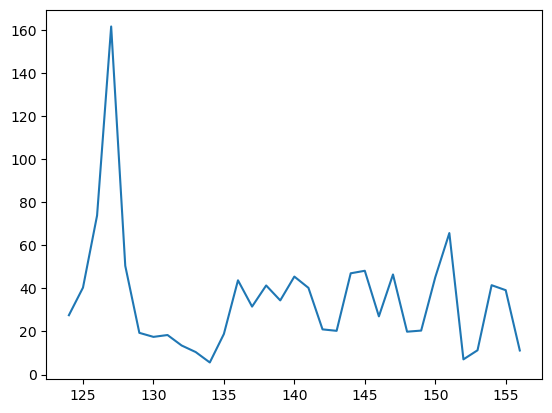

In [221]:
plt.plot(all_ctd_seasonal_strat[all_ctd_seasonal_strat.Season == "Winter"].pea)
plt.show()

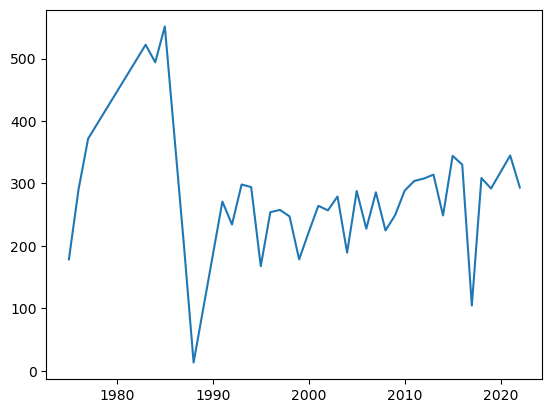

In [222]:
plt.plot(Seasonal_Strat.iloc[:39,:].year, Seasonal_Strat.iloc[:39,:].pea)
plt.show()

In [228]:
all_ctd_seasonal_strat = all_ctd_seasonal_strat.drop('index', axis=1)


In [233]:
all_ctd_seasonal_strat.to_csv('Stratification_2025.csv')

In [64]:
seawolf1 = pn.read_csv('~/Desktop/NYB_Indicators_Calculations/CalculateIndicators/WaterTemperature/data/CTD_seawolf_DEC12_2022.csv')

In [73]:
test_seawolf = fCNV('/Users/lauragruenburg/Downloads/NY1902_05_1_1.cnv')

CNVError: 'There are no rules able to parse the input. File: /Users/lauragruenburg/Downloads/NY1902_05_1_1.cnv'

In [74]:
pip install ctd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ctd]
Note: you may need to restart the kernel to use updated packages.


In [75]:
import ctd

In [78]:
test = ctd.from_cnv('/Users/lauragruenburg/Downloads/NYOS2006_C24.cnv')

In [80]:
getattr(test, 'latitude')

AttributeError: 'DataFrame' object has no attribute 'latitude'

In [ ]:
potential_energy = cast1
for i in np.unique(temp_yy_salt_yy.cast_number):
    

In [ ]:
unique_cast = ctd_casts2[ctd_casts2.cast_number == 1]
seafloor = unique_cast[unique_cast.Depth.astype(float) == unique_cast.Depth.astype(float).max()]

for i in np.arange(2,28652):
    unique_cast = ctd_casts2[ctd_casts2.cast_number == i]
    bottom = unique_cast[unique_cast.Depth.astype(float) == unique_cast.Depth.astype(float).max()]
    seafloor = pn.concat([seafloor,bottom])

seafloor = seafloor.reset_index(drop = True)

In [ ]:
seafloor

In [ ]:
# identify which ones are in the nyb polygon
NYB = gpd.read_file('Datasets/Shapefiles/PlanningArea_NYocean_NYSDOS.shp')

In [ ]:
NYB = NYB.to_crs('EPSG:4326')
NYB

In [ ]:
seafloor['geometry'] = gpd.points_from_xy(seafloor.Longitude, seafloor.Latitude, crs="EPSG:4326")
seafloor_gpd = gpd.GeoDataFrame(data=seafloor, geometry='geometry')

seafloor_nyb = gpd.sjoin(left_df=seafloor_gpd, right_df=NYB, how='left')
#data_strata = data_strata[data_strata['TYPE'] == Strata[Strata['STR_NAME'] == 14].TYPE[14-1]]

#for i in range(11, 22):
#    data_new = gpd.sjoin(left_df=data_gpd, right_df=Strata[Strata['STR_NAME'] == i], how='left')
#    data_new = data_new[data_new['TYPE'] == Strata[Strata['STR_NAME'] == i].TYPE[i-1]]
#    data_strata = pd.concat([data_strata, data_new])

In [ ]:
seafloor_nyb = seafloor_nyb[np.isnan(seafloor_nyb['Area_SqMi']) == False]

In [ ]:
seafloor_nyb = seafloor_nyb.drop(['index_right', 'ID', 'area_m', 'dummy', 'Shape_Leng', 'Shape_Area', 'Area_SqMi'], axis = 1).reset_index(drop = True)


In [ ]:
# identify if they are onshore etc.
Strata = gpd.read_file('Datasets/Shapefiles/SMIT_ECOMON_STRATA.shp')
Strata

In [ ]:
#10-21
seafloor_nyb['geometry'] = gpd.points_from_xy(seafloor_nyb.Longitude, seafloor_nyb.Latitude, crs="EPSG:4269")
seafloor_nyb_gpd = gpd.GeoDataFrame(data=seafloor_nyb, geometry='geometry').to_crs('EPSG:4269')

seafloor_strata = gpd.sjoin(left_df=seafloor_nyb_gpd, right_df=Strata[Strata['STR_NAME'] == 10], how='left')
seafloor_strata = seafloor_strata[seafloor_strata['TYPE'] == Strata[Strata['STR_NAME'] == 14].TYPE[14-1]]

for i in range(11, 22):
    seafloor_new = gpd.sjoin(left_df=seafloor_gpd.to_crs('EPSG:4269'), right_df=Strata[Strata['STR_NAME'] == i], how='left')
    seafloor_new = seafloor_new[seafloor_new['TYPE'] == Strata[Strata['STR_NAME'] == i].TYPE[i-1]]
    seafloor_strata = pn.concat([seafloor_strata, seafloor_new])

In [ ]:
def get_season(date):
    month = date.month
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

# Apply the function to create a new 'season' column
seafloor_strata['season'] =seafloor_strata['date'].apply(get_season)

In [ ]:
fig,ax = plt.subplots(nrows = 4, ncols = 4)
i=0
j=0
for location in np.unique(seafloor_strata.TYPE):
    j=0
    for seas in np.unique(seafloor_strata.season):
        subset_loc = seafloor_strata[seafloor_strata.TYPE == location]
        subset_loc_season = subset_loc[subset_loc.season == seas]
        year_count = subset_loc_season.date.dt.year.value_counts()
        ax[i,j].bar(year_count.index, year_count)
        ax[i,j].set_title(location + ' ' + seas)
        j = j+1
    i = i+1
plt.show()

In [ ]:
# for each season, shelf location and year plot how many measurements are there

In [ ]:
year_counts = seafloor_strata.date.dt.year.value_counts()
year_counts

In [ ]:
i=1
cast = ctd[starts[i]:starts[i+1]]
cast['one'] = cast['one'].map(str.strip)
    
Latitude = cast[cast['one'].str.contains('Latitude')].three.values.astype('float')
    
Longitude = cast[cast['one'].str.contains('Longitude')].three.values.astype('float')
    
Year = cast[cast['one'].str.contains('Year')].three.values.astype(int)
    
Month = cast[cast['one'].str.contains('Month')].three.values.astype(int)
    
Day = cast[cast['one'].str.contains('Day')].three.values.astype(int)
    
date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])
    
date = pn.to_datetime(date_str)
    
Prof_Flag = cast[cast['one'].str.contains('Prof-Flag')].three.values.astype('int')
    
start = cast[cast['one'].str.contains('VARIABLES')].index[0]
    
stop = cast[cast['one'].str.contains('VARIABLES')].index[1]
    
    
yndepth = np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0].any()
    
yntemp = np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0].any()
    
ynsalt = np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0].any()
    
ynph = np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0].any()
    
ynoxygen = np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0].any()


if yndepth == True:
    Depth = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
    Depth_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]+1]]

if yntemp == True:
    Temp = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]
    Temp_var = Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values
    Temp_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]+1]]
    Temp_flag_var = Temp_flag.reset_index()[2:][Temp_flag.reset_index()[2:].columns[1]].values
else:
    Temp_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    Temp_flag_var = npnp.full(len(Depth.reset_index()[2:]), np.nan)

if  ynsalt == True:
    Salt = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]]]
    Salt_var = Salt.reset_index()[2:][Salt.reset_index()[2:].columns[1]].values
    Salt_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]+1]]
    Salt_flag_var = Salt_flag.reset_index()[2:][Salt_flag.reset_index()[2:].columns[1]].values
else:
    Salt_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    Salt_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
if  ynph == True:
    pH = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]]]
    pH_var = pH.reset_index()[2:][pH.reset_index()[2:].columns[1]].values
    pH_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]+1]]
    pH_flag_var = pH_flag.reset_index()[2:][pH_flag.reset_index()[2:].columns[1]].values
else:
    pH_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    pH_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
if  ynoxygen == True:
    Oxygen = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]]]
    Oxygen_var = Oxygen.reset_index()[2:][Oxygen.reset_index()[2:].columns[1]].values
    Oxygen_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]+1]]
    Oxygen_flag_var = Oxygen_flag.reset_index()[2:][Oxygen_flag.reset_index()[2:].columns[1]].values
else:
    Oxygen_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    Oxygen_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)

df = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                              'date': np.repeat(date, len(Depth.reset_index()[2:])),
                              'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                              'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                              'Prof-Flag': np.repeat(Prof_Flag, len(Depth.reset_index()[2:])),
                              'Depth': Depth.reset_index()[2:].two.values,
                              'Depth-Flag': Depth_flag.reset_index()[2:][Depth_flag.reset_index()[2:].columns[1]].values,
                              'Temp': Temp_var,
                              'Temp-Flag': Temp_flag_var,
                              'Salt': Salt_var,
                              'Salt-Flag': Salt_flag_var,
                              'pH': pH_var,
                              'pH-Flag': pH_flag_var,
                              'Oxygen': Oxygen_var,
                              'Oxygen-Flag': Oxygen_flag_var})

In [ ]:
df

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    starts = ctd[ctd.one=='#--------------------------------------------------------------------------------'].index
    
    #Make the initial dataframe with the first cast
    i=0
    cast = ctd[starts[i]:starts[i+1]]
    cast['one'] = cast['one'].map(str.strip)
    Latitude = cast[cast['one'].str.contains('Latitude')].three.values.astype('float')
    Longitude = cast[cast['one'].str.contains('Longitude')].three.values.astype('float')
    Year = cast[cast['one'].str.contains('Year')].three.values.astype(int)
    Month = cast[cast['one'].str.contains('Month')].three.values.astype(int)
    Day = cast[cast['one'].str.contains('Day')].three.values.astype(int)
    date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])
    date = pn.to_datetime(date_str)
    Prof_Flag = cast[cast['one'].str.contains('Prof-Flag')].three.values.astype('int')
    start = cast[cast['one'].str.contains('VARIABLES')].index[0]
    stop = cast[cast['one'].str.contains('VARIABLES')].index[1]
    
    yndepth = np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0].any()
    yntemp = np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0].any()
    ynsalt = np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0].any()
    ynph = np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0].any()
    ynoxygen = np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0].any()
    
    if yndepth == True:
        Depth = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
        Depth_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]+1]]
    
    if yntemp == True:
        Temp = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]
        Temp_var = Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values
        Temp_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]+1]]
        Temp_flag_var = Temp_flag.reset_index()[2:][Temp_flag.reset_index()[2:].columns[1]].values
    else:
        Temp_var = np.full(len(Depth.reset_index()[2:]), np.nan)
        Temp_flag_var = npnp.full(len(Depth.reset_index()[2:]), np.nan)
    
    if  ynsalt == True:
        Salt = cast[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]]]
        Salt_var = Salt.reset_index()[2:][Salt.reset_index()[2:].columns[1]].values
        Salt_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]+1]]
        Salt_flag_var = Salt_flag.reset_index()[2:][Salt_flag.reset_index()[2:].columns[1]].values
    else:
        Salt_var = np.full(len(Depth.reset_index()[2:]), np.nan)
        Salt_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    if  ynph == True:
        pH = cast[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]]]
        pH_var = pH.reset_index()[2:][pH.reset_index()[2:].columns[1]].values
        pH_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]+1]]
        pH_flag_var = pH_flag.reset_index()[2:][pH_flag.reset_index()[2:].columns[1]].values
    else:
        pH_var = np.full(len(Depth.reset_index()[2:]), np.nan)
        pH_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    if  ynoxygen == True:
        Oxygen = cast[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]]]
        Oxygen_var = Oxygen.reset_index()[2:][Oxygen.reset_index()[2:].columns[1]].values
        Oxygen_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]+1]]
        Oxygen_flag_var = Oxygen_flag.reset_index()[2:][Oxygen_flag.reset_index()[2:].columns[1]].values
    else:
        Oxygen_var = np.full(len(Depth.reset_index()[2:]), np.nan)
        Oxygen_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    
    ctd_casts = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                              'date': np.repeat(date, len(Depth.reset_index()[2:])),
                              'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                              'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                              'Prof-Flag': np.repeat(Prof_Flag, len(Depth.reset_index()[2:])),
                              'Depth': Depth.reset_index()[2:].two.values,
                              'Depth-Flag': Depth_flag.reset_index()[2:][Depth_flag.reset_index()[2:].columns[1]].values,
                              'Temp': Temp_var,
                              'Temp-Flag': Temp_flag_var,
                              'Salt': Salt_var,
                              'Salt-Flag': Salt_flag_var,
                              'pH': pH_var,
                              'pH-Flag': pH_flag_var,
                              'Oxygen': Oxygen_var,
                              'Oxygen-Flag': Oxygen_flag_var})

    for i in np.arange(1,39519):
        cast = ctd[starts[i]:starts[i+1]]
        cast['one'] = cast['one'].map(str.strip)
        if cast[cast['one'].str.contains('VARIABLES')].any().any() == True:
            Latitude = cast[cast['one'].str.contains('Latitude')].three.values.astype('float')
            Longitude = cast[cast['one'].str.contains('Longitude')].three.values.astype('float')
            Year = cast[cast['one'].str.contains('Year')].three.values.astype(int)
            Month = cast[cast['one'].str.contains('Month')].three.values.astype(int)
            Day = cast[cast['one'].str.contains('Day')].three.values.astype(int)
            date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])
            date = pn.to_datetime(date_str)
            Prof_Flag = cast[cast['one'].str.contains('Prof-Flag')].three.values.astype('int')
            start = cast[cast['one'].str.contains('VARIABLES')].index[0]
            stop = cast[cast['one'].str.contains('VARIABLES')].index[1]
    
            yndepth = np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0].any()
            yntemp = np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0].any()
            ynsalt = np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0].any()
            ynph = np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0].any()
            ynoxygen = np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0].any()
    
            if yndepth == True:
                Depth = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
                Depth_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]+1]]
    
            if yntemp == True:
                Temp = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]
                Temp_var = Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values
                Temp_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]+1]]
                Temp_flag_var = Temp_flag.reset_index()[2:][Temp_flag.reset_index()[2:].columns[1]].values
            else:
                Temp_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                Temp_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
    
            if  ynsalt == True:
                Salt = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]]]
                Salt_var = Salt.reset_index()[2:][Salt.reset_index()[2:].columns[1]].values
                Salt_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]+1]]
                Salt_flag_var = Salt_flag.reset_index()[2:][Salt_flag.reset_index()[2:].columns[1]].values
            else:
                Salt_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                Salt_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
            if  ynph == True:
                pH = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]]]
                pH_var = pH.reset_index()[2:][pH.reset_index()[2:].columns[1]].values
                pH_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('pH') == True)[0][0]+1]]
                pH_flag_var = pH_flag.reset_index()[2:][pH_flag.reset_index()[2:].columns[1]].values
            else:
                pH_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                pH_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)
            if  ynoxygen == True:
                Oxygen = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]]]
                Oxygen_var = Oxygen.reset_index()[2:][Oxygen.reset_index()[2:].columns[1]].values
                Oxygen_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Oxygen') == True)[0][0]+1]]
                Oxygen_flag_var = Oxygen_flag.reset_index()[2:][Oxygen_flag.reset_index()[2:].columns[1]].values
            else:
                Oxygen_var = np.full(len(Depth.reset_index()[2:]), np.nan)
                Oxygen_flag_var = np.full(len(Depth.reset_index()[2:]), np.nan)

            df = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                                  'date': np.repeat(date, len(Depth.reset_index()[2:])),
                                  'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                                  'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                                  'Prof-Flag': np.repeat(Prof_Flag, len(Depth.reset_index()[2:])),
                                  'Depth': Depth.reset_index()[2:].two.values,
                                  'Depth-Flag': Depth_flag.reset_index()[2:][Depth_flag.reset_index()[2:].columns[1]].values,
                                  'Temp': Temp_var,
                                  'Temp-Flag': Temp_flag_var,
                                  'Salt': Salt_var,
                                  'Salt-Flag': Salt_flag_var,
                                  'pH': pH_var,
                                  'pH-Flag': pH_flag_var,
                                  'Oxygen': Oxygen_var,
                                  'Oxygen-Flag': Oxygen_flag_var})
            ctd_casts = pn.concat([ctd_casts, df])

In [ ]:
ctd_casts


In [ ]:
if cast[cast['one'].str.contains('VARIABLES')].any().any() == False:
 

In [ ]:
ctd[starts[i+1]:starts[i+1+1]]

In [ ]:
CTD_formatted = get_ctd(ctd)
CTD_formatted

In [ ]:
i

In [ ]:
Depth_flag.reset_index()[2:]

In [ ]:
col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]+1]

In [ ]:
Depth = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
Depth_flag = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]+1]]

Depth_flag.reset_index()

In [ ]:
i=0
cast = ctd[starts[i]:starts[i+1]]
cast['one'] = cast['one'].map(str.strip)
Latitude = cast[cast['one'].str.contains('Latitude')].three.values.astype('float')
Longitude = cast[cast['one'].str.contains('Longitude')].three.values.astype('float')
Year = cast[cast['one'].str.contains('Year')].three.values.astype(int)
Month = cast[cast['one'].str.contains('Month')].three.values.astype(int)
Day = cast[cast['one'].str.contains('Day')].three.values.astype(int)
date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])
date = pn.to_datetime(date_str)
start = cast[cast['one'].str.contains('VARIABLES')].index[0]
stop = cast[cast['one'].str.contains('VARIABLES')].index[1]
yndepth = np.where(cast[start:stop].loc[start].str.contains('Depth') == True)[0].any()
yntemp = np.where(cast[start:stop].loc[start].str.contains('Temp') == True)[0].any()
ynsalt = np.where(cast[start:stop].loc[start].str.contains('Sal') == True)[0].any()
if yndepth == True:
    Depth = cast[start:stop][col_names[np.where(cast[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
else:
    Depth = 'no'
if yntemp == True:
    Temp = cast[start:stop][col_names[np.where(cast[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]
else:
    Temp = 'no'
if  ynsalt == True:
    Salt = cast[start:stop][col_names[np.where(cast[start:stop].loc[start].str.contains('Sal') == True)[0][0]]]
else:
    Salt = 'no'
if yndepth == True and yntemp == True and ynsalt == False:
    ctd_casts = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                              'date': np.repeat(date, len(Depth.reset_index()[2:])),
                       'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                       'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                       'Depth': Depth.reset_index()[2:].two.values,
                       'Temp': Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values})
if yndepth == True and yntemp == True and ynsalt == True: 
    ctd_casts = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                              'date': np.repeat(date, len(Depth.reset_index()[2:])),
                       'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                       'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                       'Depth': Depth.reset_index()[2:].two.values,
                       'Temp': Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values,
                        'Salt': Salt.reset_index()[2:][Salt.reset_index()[2:].columns[1]].values})

In [ ]:
ctd_casts = pn.DataFrame({'date': np.repeat(date, len(Depth.reset_index()[2:])),
                       'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                       'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                       'Depth': Depth.reset_index()[2:].two.values,
                       'Temp': Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values})

In [ ]:
ctd_casts

In [ ]:
Temp

In [ ]:

for i in np.arange(1,2000):
    cast = ctd[starts[i]:starts[i+1]]
    cast['one'] = cast['one'].map(str.strip)
    Latitude = cast[cast['one'].str.contains('Latitude')].three.values.astype('float')
    Longitude = cast[cast['one'].str.contains('Longitude')].three.values.astype('float')
    Year = cast[cast['one'].str.contains('Year')].three.values.astype(int)
    Month = cast[cast['one'].str.contains('Month')].three.values.astype(int)
    Day = cast[cast['one'].str.contains('Day')].three.values.astype(int)
    date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])
    date = pn.to_datetime(date_str)
    start = cast[cast['one'].str.contains('VARIABLES')].index[0]
    stop = cast[cast['one'].str.contains('VARIABLES')].index[1]
    yndepth = np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0].any()
    yntemp = np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0].any()
    ynsalt = np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0].any()
    if yndepth == True:
        Depth = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]
    if yntemp == True:
        Temp = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]
    if  ynsalt == True:
        Salt = cast.loc[start:stop][col_names[np.where(cast.loc[start:stop].loc[start].str.contains('Sal') == True)[0][0]]]
    if yndepth == True and yntemp == True and ynsalt == False:
        df = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                           'date': np.repeat(date, len(Depth.reset_index()[2:])),
                       'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                       'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                       'Depth': Depth.reset_index()[2:].two.values,
                       'Temp': Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values})
    if yndepth == True and yntemp == True and ynsalt == True: 
        df = pn.DataFrame({'cast_number': np.repeat(i+1, len(Depth.reset_index()[2:])),
                           'date': np.repeat(date, len(Depth.reset_index()[2:])),
                       'Latitude': np.repeat(Latitude, len(Depth.reset_index()[2:])),
                       'Longitude': np.repeat(Longitude, len(Depth.reset_index()[2:])),
                       'Depth': Depth.reset_index()[2:].two.values,
                       'Temp': Temp.reset_index()[2:][Temp.reset_index()[2:].columns[1]].values,
                        'Salt': Salt.reset_index()[2:][Salt.reset_index()[2:].columns[1]].values})
    ctd_casts = pn.concat([ctd_casts, df])
    

In [ ]:
ctd_casts

In [ ]:
cast.loc[start:stop]

In [ ]:
np.where(cast[start:stop].loc[start].str.contains('Depth') == True)[0]

In [ ]:
Depth.reset_index()[2:]

In [ ]:
for colname in col_names:
    test_cast[colname] = test_cast[colname].map(str.strip)

In [ ]:
test_cast['one'] = test_cast['one'].map(str.strip)

In [ ]:
Latitude = test_cast[test_cast['one'].str.contains('Latitude')].three.values.astype('float')

In [ ]:
Longitude = test_cast[test_cast['one'].str.contains('Longitude')].three.values.astype('float')

In [ ]:
Year = test_cast[test_cast['one'].str.contains('Year')].three.values.astype(int)
Month = test_cast[test_cast['one'].str.contains('Month')].three.values.astype(int)
Day = test_cast[test_cast['one'].str.contains('Day')].three.values.astype(int)

In [ ]:
date_str = str(Year[0]) + '-' +str(Month[0]) +'-'+ str(Day[0])

In [ ]:
date = pn.to_datetime(date_str)

In [ ]:
start = test_cast[test_cast['one'].str.contains('VARIABLES')].index[0]
stop = test_cast[test_cast['one'].str.contains('VARIABLES')].index[1]

In [ ]:
np.where(test_cast[start:stop].loc[20].str.contains('Depth') == True)[0][0]

In [ ]:
Depth = test_cast[start:stop][col_names[np.where(test_cast[start:stop].loc[start].str.contains('Depth') == True)[0][0]]]


In [ ]:
Temp = test_cast[start:stop][col_names[np.where(test_cast[start:stop].loc[start].str.contains('Temp') == True)[0][0]]]


In [ ]:
test_cast[start:stop].str.strip

In [ ]:
str.strip

In [ ]:
ctd[1525813:1525833]

In [ ]:
asciitest = pn.read_csv('/Users/lauragruenburg/Downloads/ocldb1756224108.487414.txt')

In [ ]:
asciitest